# Python Controle Discret

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import StateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Control.DiscretePID import DiscretePID

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridControlLoop
from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

import numpy as np
import control as ct
import matplotlib.pyplot as plt



In [2]:
%matplotlib inline

## Mise en place

#### Système
Ici, on spécifie l'état initial, la méthode TransferFunctionModel() donne sa fonction de tranfert qu'on met ensuite dans le simualteur de fonctions de transfert

In [3]:
X_0 = np.array([[0], [0]])
model = TransferFunctionModel(ballbeam_config)
plant_sim = TFSimulator(model.Tf_dis, 0)

#### Réponse inditielle et impultionelle 
Le but est de comparer notre simualtion a celle de la librairie python

1) Réponse impulsionelle

In [4]:


## simulateur 
impulse_logger=SimLog()
impulse_logger=run_impulse_response_sim(plant_sim,ballbeam_config,0.0,impulse_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.impulse_response(model.Tf_dis, t)

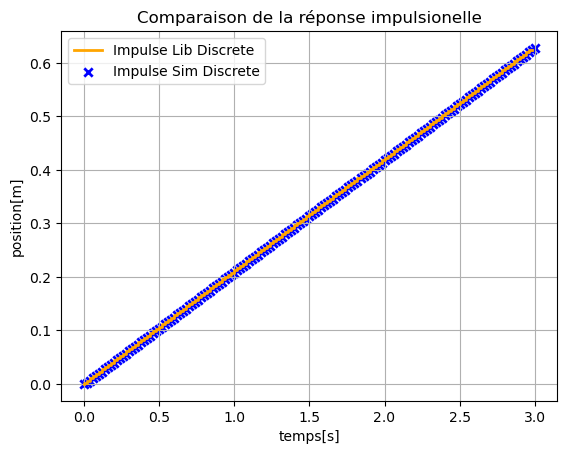

In [5]:
fig1=plt.figure()
plt.step(
    t,
    y_lib,
    color='orange',
    linewidth=2,
    label="Impulse Lib Discrete"
)
plt.scatter(
    impulse_logger.t_hist,
    impulse_logger.y_hist,
    color='blue',
    marker='x',
    label="Impulse Sim Discrete",
    linewidth=2,
)


plt.grid()
plt.title('Comparaison de la réponse impulsionelle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
plt.savefig('Réponse_Impulsionelle_Discrete.png')
plt.show()


##### Réponse inditielle

In [6]:
## simulateur 
step_logger=SimLog()
step_logger=run_step_response_sim(plant_sim,ballbeam_config,0.0,step_logger)
## librairie python
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(model.Tf_dis, t)

In [7]:
_, y_lib = ct.step_response(model.Tf_cont, t)

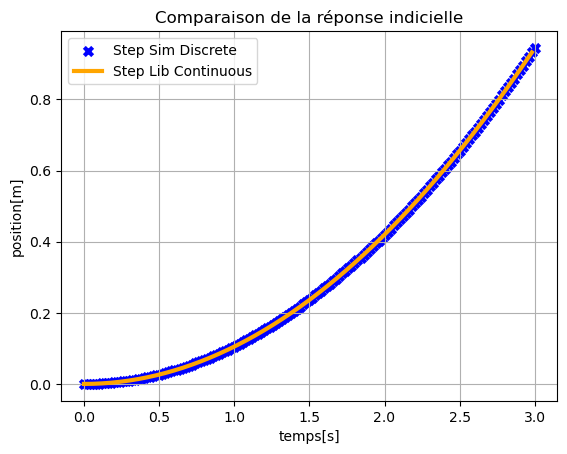

In [8]:
fig3=plt.figure()
plt.scatter(
    step_logger.t_hist,
    step_logger.y_hist,
    color='blue',
    marker='x',
    label="Step Sim Discrete",
    linewidth=3,
)

plt.plot(
    t,
    y_lib,
    color='orange',
    linestyle='-',
    linewidth=3,
    label="Step Lib Continuous"
)
plt.grid()
plt.title('Comparaison de la réponse indicielle')
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
plt.savefig('Réponse_Indicielle_Continue.png')
plt.show()


## Controle PID et validation


#### Mise en place du PID

In [9]:
ballbeam_config.T=3

In [ ]:
kp, ki, kd = 50, 0, 50
r = 1
PID = DiscretePID(kp,ki,kd,10,ballbeam_config.dt)
PID.setReference(r)
controller_sim = TFSimulator(PID.PID_TF_dis, 0)
PID.reset()

#### Modele en espace d'états (utilisé pour la simulation hybride)

In [11]:
StateSpace_Ball_Beam=StateSpaceModel(ballbeam_config)
hybrid_loop=HybridControlLoop(StateSpace_Ball_Beam,controller_sim,ballbeam_config)


In [12]:
logger_hybrid_step = SimLog()

logger_hybrid_step = hybrid_loop.run_step_response( X_0,logger_hybrid_step)


In [13]:
t = np.arange(0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib1 = ct.step_response(model.Tf_cont, t)

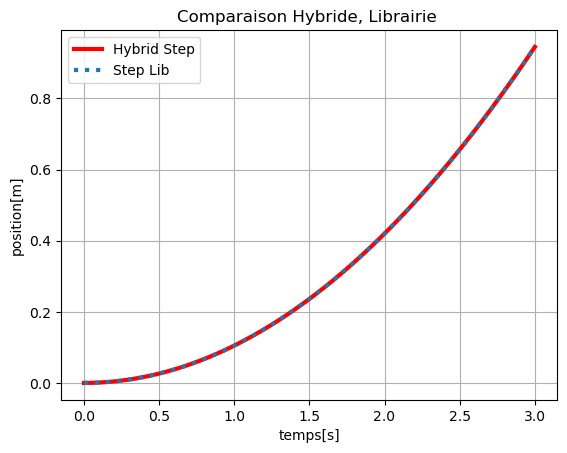

In [14]:
plt.figure()

plt.plot(
    logger_hybrid_step.t_hist,
    logger_hybrid_step.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Step"
)
plt.plot(
    t,
    y_lib1,
    linestyle=':',
    linewidth=3,
    label="Step Lib"
)
plt.title("Comparaison Hybride, Librairie ")
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')
plt.savefig('Réponse_Indicielle_Hybride.png')
plt.show()

In [16]:
hybrid_loop = HybridControlLoop(StateSpace_Ball_Beam,PID,ballbeam_config)
logger_hybrid = SimLog()

logger_hybrid = hybrid_loop.run_continuous_control_loop( X_0,logger_hybrid)


In [17]:
L = PID.PID_TF_cont * model.Tf_cont
T = ct.feedback(L, 1)

t = np.arange(
    0,
    ballbeam_config.T,
    ballbeam_config.dt
)

_, y_lib = ct.step_response(T, t)

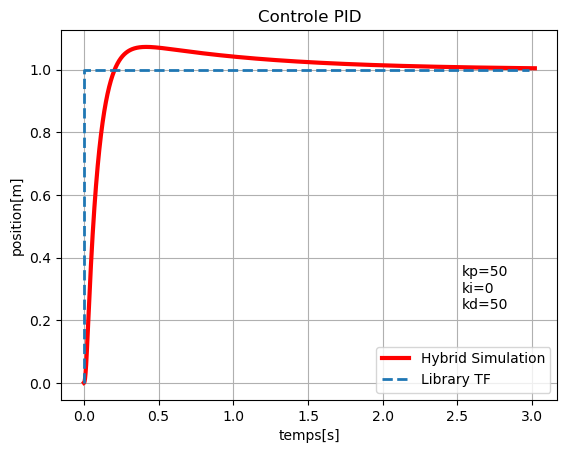

1e-05


In [18]:
plt.figure()

plt.plot(
    logger_hybrid.t_hist,
    logger_hybrid.y_hist,
    color='red',
    linewidth=3,
    linestyle='-',
    label="Hybrid Simulation"
)
plt.step(t, y_lib, label="Library TF",linewidth=2,
    linestyle='--',)
plt.title("Controle PID")
text='kp='+str(kp)+'\n'+'ki='+str(ki)+'\n'+'kd='+str(kd)
plt.figtext(0.75,0.3,text)
plt.grid()
plt.legend()
plt.xlabel('temps[s]')
plt.ylabel('position[m]')

plt.savefig('Réponse_Indicielle_PID.png')
plt.show()
x=hybrid_loop.dt_plant
print(x)


In [ ]:
print(y_lib[:5])
print(logger_hybrid.y_hist[:5])
print(np.array(logger_hybrid.y_hist[:5]) / y_lib[:5])

[0.         1.00001054 1.00003807 1.00003805 1.00003804]
[0.0, 5.355000000000002e-08, 1.6065000000000005e-07, 3.213000000000001e-07, 5.355000000000002e-07]
[           nan 5.35494358e-08 1.60643885e-07 3.21287774e-07
 5.35479631e-07]


C:\Users\adamc\AppData\Local\Temp\ipykernel_33012\3725541128.py:3: RuntimeWarning: invalid value encountered in divide
  print(np.array(logger_hybrid.y_hist[:5]) / y_lib[:5])
